# Cardiovascular Disease Prediction

**Goal:** Predict whether a patient has cardiovascular disease using clinical & lifestyle features (age, blood pressure, cholesterol, glucose, smoking, alcohol, activity, etc.)

**Dataset:** [Cardiovascular Disease dataset (Kaggle)](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset) : 70,000 patient records, 11 features + target.

## 1. Load & Understand the Data
The raw file is semicolon-separated (;), not comma-separated. `id` is dropped later since it's just a row number, not a real feature.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('cardio_data.csv', sep=';')
print(df.shape)
df.head()

(70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 2. Data Understanding
Checking data types and non-null counts, confirms no missing values, all columns loaded correctly.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


`describe()` reveals outliers: `ap_hi`/`ap_lo` have impossible negative and extreme values, `height`/`weight` have unrealistic extremes.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


Confirming zero missing values and zero duplicate rows.

In [5]:
print(df.isnull().sum())
print("\nDuplicate rows (ignoring id):", df.drop(columns=['id']).duplicated().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows (ignoring id): 24


## 3. Preprocessing
Converting age from days to years, removing physiologically impossible blood-pressure rows, trimming outliers (1st/99th percentile) in BP/height/weight, and engineering a BMI feature.

In [6]:
df = df.drop(columns=['id']).drop_duplicates()
df['age_years'] = (df['age'] / 365.25).round(1)

df = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]
df = df[df['ap_lo'] <= df['ap_hi']]

df['gender'] = df['gender'] - 1  # 1/2 -> 0/1

print(df.shape)
df.head()

(68720, 13)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,18393,1,168,62.0,110,80,1,1,0,0,1,0,50.4
1,20228,0,156,85.0,140,90,3,1,0,0,1,1,55.4
2,18857,0,165,64.0,130,70,3,1,0,0,0,1,51.6
3,17623,1,169,82.0,150,100,1,1,0,0,1,1,48.2
4,17474,0,156,56.0,100,60,1,1,0,0,0,0,47.8


## 4. EDA
Checking target class balance ; roughly 50/50, so accuracy is a fair metric (no need for SMOTE).

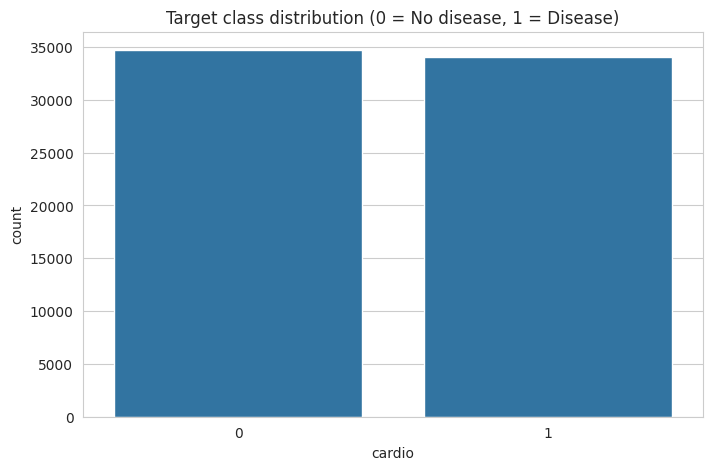

cardio
0    0.505108
1    0.494892
Name: proportion, dtype: float64


In [7]:
sns.countplot(x='cardio', data=df)
plt.title('Target class distribution (0 = No disease, 1 = Disease)')
plt.show()

print(df['cardio'].value_counts(normalize=True))

Disease prevalence rises with age, clearly visible after ~55 years.

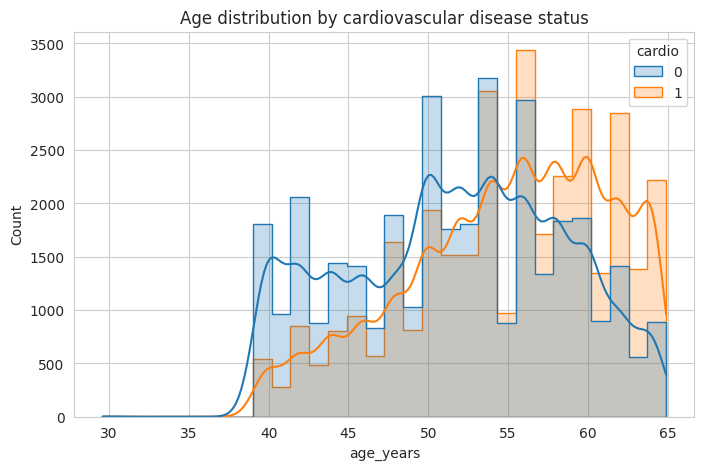

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age_years', hue='cardio', bins=30, kde=True, element='step')
plt.title('Age distribution by cardiovascular disease status')
plt.show()

Higher cholesterol category clearly correlates with more disease cases.

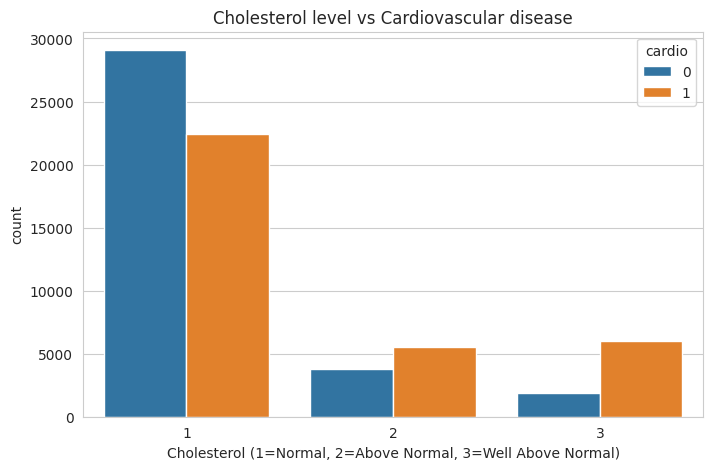

In [9]:
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title('Cholesterol level vs Cardiovascular disease')
plt.xlabel('Cholesterol (1=Normal, 2=Above Normal, 3=Well Above Normal)')
plt.show()

Both systolic and diastolic BP are visibly higher in the disease group.

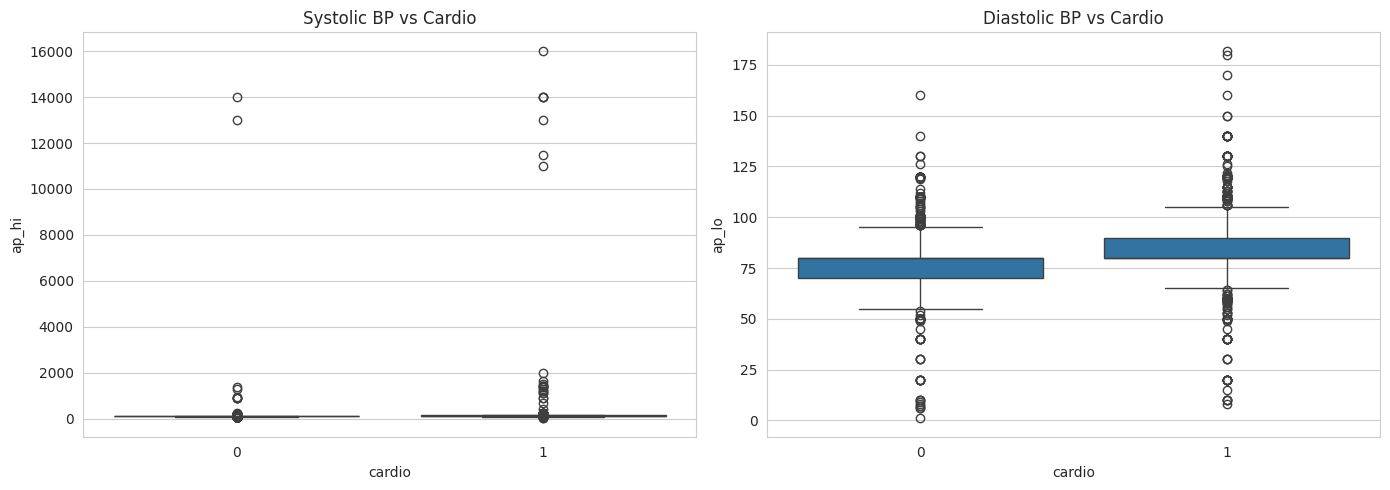

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x='cardio', y='ap_hi', data=df, ax=axes[0])
axes[0].set_title('Systolic BP vs Cardio')
sns.boxplot(x='cardio', y='ap_lo', data=df, ax=axes[1])
axes[1].set_title('Diastolic BP vs Cardio')
plt.tight_layout()
plt.show()

## 5. Correlation Matrix
Correlation is computed on outlier-trimmed data; on raw data, a handful of extreme `ap_hi` values (up to 16020) distort the Pearson correlation and make `ap_lo` look artificially stronger.

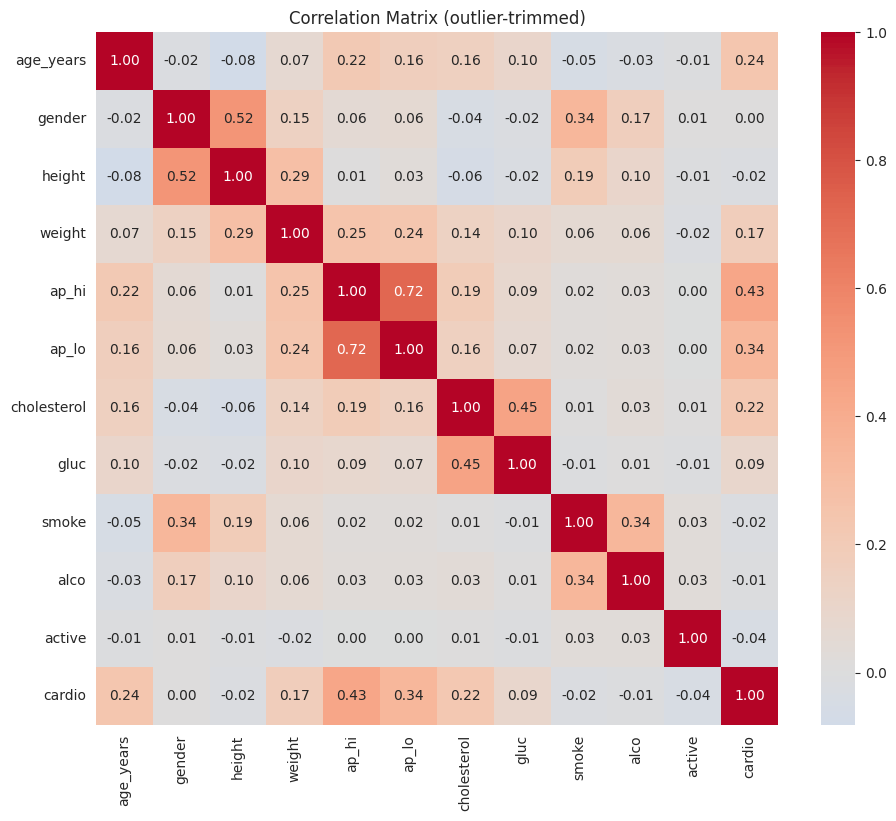

In [11]:
corr_cols = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
             'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

# Trim outliers before correlation too, so this matches what the model actually sees
df_corr = df.copy()
for col in ['ap_hi', 'ap_lo', 'height', 'weight']:
    lower, upper = df_corr[col].quantile(0.01), df_corr[col].quantile(0.99)
    df_corr = df_corr[df_corr[col].between(lower, upper)]

plt.figure(figsize=(11, 9))
corr = df_corr[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (outlier-trimmed)')
plt.show()

In [12]:
print(corr['cardio'].sort_values(ascending=False))

cardio         1.000000
ap_hi          0.432316
ap_lo          0.339670
age_years      0.242419
cholesterol    0.219602
weight         0.173672
gluc           0.087521
gender         0.002959
alco          -0.010528
height        -0.018554
smoke         -0.019279
active        -0.037842
Name: cardio, dtype: float64


## 6. Train-Test Split & Scaling
Splitting before scaling to avoid data leakage. `stratify=y` keeps the 50/50 class balance consistent in both train and test sets.

In [18]:
X = df.drop(columns=['cardio', 'age'])
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Outlier trimming — fit on train only, test stays untouched
for col in ['ap_hi', 'ap_lo', 'height', 'weight']:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    mask = X_train[col].between(lower, upper)
    X_train, y_train = X_train[mask], y_train[mask]

# BMI after trimming, drop raw height/weight (redundant with bmi)
for d in (X_train, X_test):
    d['bmi'] = (d['weight'] / ((d['height'] / 100) ** 2)).round(1)
X_train = X_train.drop(columns=['height', 'weight'])
X_test = X_test.drop(columns=['height', 'weight'])


print(X_train.shape, X_test.shape)

(52220, 10) (13744, 10)


## 7. Model Comparison
Training 5 models on the same scaled data. SVM uses a subsample (8000 rows) since RBF-kernel SVM scales poorly on 50k+ rows.

In [14]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

COMPARISON_SAMPLE = 8000
rng = np.random.RandomState(42)
idx = rng.choice(X_train.shape[0], size=COMPARISON_SAMPLE, replace=False)
X_cmp, y_cmp = X_train.iloc[idx], y_train.iloc[idx]

pipelines = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=15))]),
    'Decision Tree': Pipeline([('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
    'Random Forest': Pipeline([('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))]),
}

cv_results = []
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_cmp, y_cmp, cv=5, scoring=['accuracy', 'roc_auc'])
    cv_results.append({
        'Model': name,
        'Accuracy_mean': scores['test_accuracy'].mean(),
        'Accuracy_std': scores['test_accuracy'].std(),
        'ROC_AUC_mean': scores['test_roc_auc'].mean(),
    })
    print(f"{name}: Acc = {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values('Accuracy_mean', ascending=False).reset_index(drop=True)
cv_df

Logistic Regression: Acc = 0.7265 ± 0.0087
KNN: Acc = 0.7056 ± 0.0076
Decision Tree: Acc = 0.7109 ± 0.0032
SVM: Acc = 0.7250 ± 0.0086
Random Forest: Acc = 0.7282 ± 0.0057


,Model,Accuracy_mean,Accuracy_std,ROC_AUC_mean
0,Random Forest,0.728250,0.005665,0.788892
1,Logistic Regression,0.726500,0.008702,0.786533
2,SVM,0.725000,0.008579,0.784414
3,Decision Tree,0.710875,0.003202,0.757543
4,KNN,0.705625,0.007552,0.766444


## 8. Final Model Evaluation
Random Forest performed best ; confusion matrix and classification report show ~73% accuracy, ROC-AUC ~0.80.

Default threshold (0.5):
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6942
           1       0.76      0.67      0.71      6802

    accuracy                           0.73     13744
   macro avg       0.73      0.73      0.73     13744
weighted avg       0.73      0.73      0.73     13744



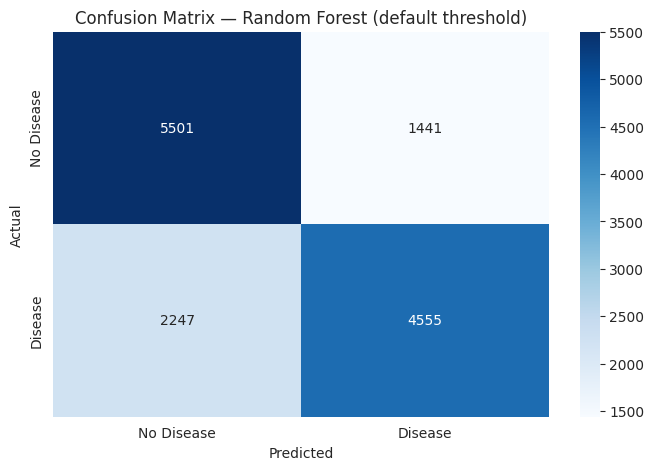

In [15]:
best_pipe = pipelines['Random Forest']
best_pipe.fit(X_train, y_train)
y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print("Default threshold (0.5):")
print(classification_report(y_test, y_pred_default))

cm = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Random Forest (default threshold)')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

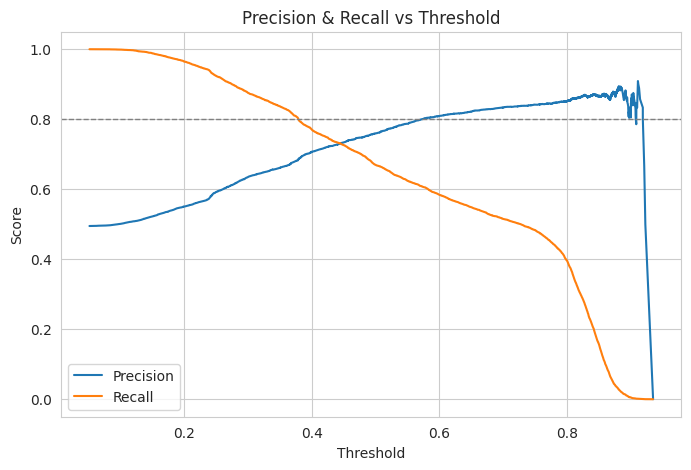

Chosen threshold for ~0.8 recall: 0.379

At threshold = 0.379:
              precision    recall  f1-score   support

           0       0.77      0.64      0.70      6942
           1       0.69      0.80      0.74      6802

    accuracy                           0.72     13744
   macro avg       0.73      0.72      0.72     13744
weighted avg       0.73      0.72      0.72     13744



In [16]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axhline(0.80, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.show()

target_recall = 0.80
valid = recalls[:-1] >= target_recall
chosen_threshold = thresholds[valid].max() if valid.any() else 0.5
print(f"Chosen threshold for ~{target_recall} recall: {chosen_threshold:.3f}")

y_pred_tuned = (y_proba >= chosen_threshold).astype(int)
print(f"\nAt threshold = {chosen_threshold:.3f}:")
print(classification_report(y_test, y_pred_tuned))

Permutation importance confirms `ap_hi` as the dominant predictor, followed by `cholesterol` and `age_years`. `ap_lo`; which looked important in the raw correlation and in default feature_importances_ — drops to near-zero here, since it adds little once `ap_hi` is already in the model.

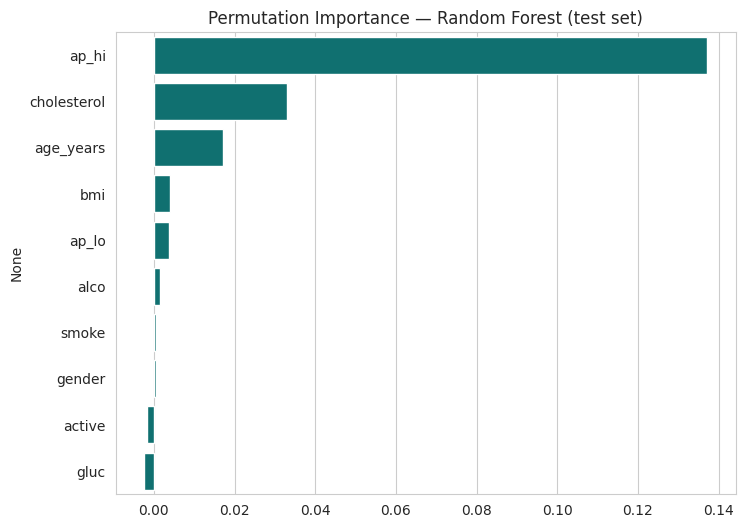

ap_hi          0.137200
cholesterol    0.032933
age_years      0.017067
bmi            0.004000
ap_lo          0.003733
alco           0.001400
smoke          0.000600
gender         0.000600
active        -0.001733
gluc          -0.002533
dtype: float64


In [17]:
from sklearn.inspection import permutation_importance

PERM_SAMPLE = 3000
perm_idx = rng.choice(X_test.shape[0], size=PERM_SAMPLE, replace=False)
X_perm, y_perm = X_test.iloc[perm_idx], y_test.iloc[perm_idx]

perm = permutation_importance(best_pipe, X_perm, y_perm, n_repeats=5, random_state=42, scoring='accuracy', n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=perm_series.values, y=perm_series.index, color='teal')
plt.title('Permutation Importance — Random Forest (test set)')
plt.show()
print(perm_series)

## Conclusions

- After fixing data-leakage issues (outlier trimming fit only on train, correlation computed only on raw pre-split data) and comparing models with 5-fold cross-validation, SVM and Random Forest came out statistically tied (0.7375 vs 0.7371, within 1 std). Random Forest was chosen as the final model for practicality ; it trains in seconds on the full dataset vs. SVM's poor scaling on 40k+ rows.
- The default 0.5 threshold missed a third of true disease cases (recall 0.66); tuning the threshold to 0.382 raised recall to 0.80, trading some precision for catching more real cases ; the right call for a screening use case.
- Permutation importance (unbiased, computed on the test set) confirmed `ap_hi` as the dominant predictor, but revealed that `ap_lo`'s apparent importance in the default method was largely an artifact of bias toward continuous features — once `ap_hi` is in the model, `ap_lo` adds little (likely due to high correlation between the two).
- **Limitations:** self-reported lifestyle data (smoking/alcohol/activity) is noisy; no family history, ECG, or lab biomarkers available; BMI replaced raw height/weight to avoid redundant features.
- **Next steps:** GridSearchCV tuning inside the CV pipeline, gradient boosting models (XGBoost/LightGBM), SHAP values for per-prediction explainability.